# Clustering

----------------------------------------------------
Machine Learning     

*Emilio Parrado Hernández eparrado@ing.uc3m.es*, *Vanessa Gómez Verdejo vanessa@tsc.uc3m.es* and *Pablo M. Olmos olmos@tsc.uc3m.es*

----------------------------------------------------

In [1]:
get_ipython().__class__.__name__ = "ZMQInteractiveShell"

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
# use seaborn plotting defaults
%config InlineBackend.figure_format = 'retina'   ##QUALITY FIGURES!!
import seaborn as sns; sns.set()
plt.rcParams["figure.figsize"] = [6,6]

# Unsupervised Learning

- In the dataset there are no true *targets* for the observations
- Try to detect or uncover **patterns** underlying the data collection such as groups.
- Typical examples of unsupervised algorithms: **K means**,  **spectral clustering**, **GMM**, **PCA**, **1-SVM**
- Examples of aplications :
 - group (partition) collections of data
 - identification of *outliers*
 - segmentation of video and audio clips
 - organization of collections of documents
 - learn probability density functions


# 1. The Clustering Problem

## Clustering general context

- **Clustering** is about finding groups in data

- Usually framed as **unsupervised learning** since there is no need of labelled data

- Useful in cases where collecting data is easy but labelling data is difficult

- Applications:
    - Image segmentation
    - Speaker/audio segmentation
    - Auto-Organisation of a collection of documents
    - Data compression
    - Biomedical applications like clustering sequences of proteins
    - Marketing and sales (groups of customers)
    




## Motivation

### Defining groups is controversial

<img src='http://www.tsc.uc3m.es/~emipar/NOTEBOOKS/Clustering_ML_health/kmeans1.png' width=1000 />

<img src='http://www.tsc.uc3m.es/~emipar/NOTEBOOKS/Clustering_ML_health/kmeans2.png' width=1000 />

<img src='http://www.tsc.uc3m.es/~emipar/NOTEBOOKS/Clustering_ML_health/kmeans3.png' width=1000 />

<img src='http://www.tsc.uc3m.es/~emipar/NOTEBOOKS/Clustering_ML_health/kmeans4.png' width=1000 />

<img src='http://www.tsc.uc3m.es/~emipar/NOTEBOOKS/Clustering_ML_health/kmeans5.png' width=1000 />

## Notation

- Data: we have $n$ observations with $d$ dimensions each. The data is stored in a matrix $X$ where each observation rests in a row.

$$
X = \left [ \begin{array}{c}
\mathbf{x}_1^\top \\
\mathbf{x}_2^\top \\
\mathbf{x}_3^\top \\
\vdots\\
\mathbf{x}_{n-1}^\top \\
\mathbf{x}_{n}^\top
\end{array}\right ] = \left [ \begin{array}{lcccr}
\left[ x_{1,1} \right. & x_{1,2} & \cdots & x_{1,d-1} & \left. x_{1,d}\right ] \\
\left[ x_{2,1} \right. & x_{2,2} & \cdots & x_{2,d-1} & \left. x_{2,d}\right ] \\
\left[ x_{3,1} \right.& x_{3,2} & \cdots & x_{3,d-1} & \left. x_{3,d}\right ] \\
\vdots & \vdots & \ddots & \vdots & \vdots\\
\left[ x_{n-1,1} \right. & x_{n-1,2} & \cdots & x_{n-1,d-1} & \left.  x_{n-1,d}\right ] \\
\left[ x_{n,1} \right. & x_{n,2} & \cdots & x_{n,d-1} &\left.  x_{n,d}\right ]
\end{array}\right ]
$$

- Groups: $K$. In some algorithms $K$ must be an input. In other algorithms there are procedures to find a reasonable value for $K$.


## Similarity functions and distances

- Data samples that are similar should end up in the same group, while data samples that are different should end up in different groups

- The starting point in clustering analysis is the definition of a similarity function or a distance that measures how close are patterns

    - **Similarity or affinity**
$$ s(\mathbf{x}_i,\mathbf{x}_j)=\begin{cases}
1, & \text{if } \mathbf{x}_i, \mathbf{x}_j \text{ should be in the same cluster},\\
0, & \text{if } \mathbf{x}_i, \mathbf{x}_j \text{ should be in different clusters}.
\end{cases} $$

    - **Distance**
$$ d(\mathbf{x}_i,\mathbf{x}_j) \begin{cases}
\to 0 & \text{if } \mathbf{x}_i, \mathbf{x}_j \text{ should be in the same cluster} \\
\to \infty & \text{if } \mathbf{x}_i, \mathbf{x}_j \text{ should be in different clusters}
\end{cases} $$

# 2. KMeans clustering
---

K means is arguably one of the most popular machine learning algorithms.

It basically consists in an **iterative**, **greedy** optimization that finds a partitioning of a data collection in $K$ groups. The partitioning pursues to minimize the distances among the members of the same group and maximize the distances among members of different groups.

## KMeans Algorithm
---

- **Input**:
  - Dataset $\{\mathbf{x}_i\}_{i=1}^n$
  - **distance** $d(\mathbf{x}_i,\mathbf{x}_j)$ and  
  - number of groups $K$

- **Initialization**: Start each group $k$, $k=1,\ldots,K$ with a random **centroid** or centre of masses $\mathbf{c}_k$. An easy and quick way to initialize is to select at random $K$ of the input samples and assign each one to a group.

- **Iterate until convergence**:

    1. **Assignment**. For $i=1,\ldots,n$, assign instance $\mathbf{x}_i$ to the group whose centroid is closer to it according to distance $d$.

    $$
    \mathbf{x}_i \text{ is assigned to cluster } C_k \text{ where } k = \operatorname{argmin}_{m=1,\dots,K} d(\mathbf{x}_i, \mathbf{c}_m)
    $$

    2. **Update centroids**. After all the instances have been assigned to a group, recompute the centre of masses (centroid) of this group as the sample average of all the members of the group:
$$
\mathbf{c}_k = \frac{1}{N_k} \sum_{\mathbf{x}_j \in C_k} \mathbf{x}_j, \quad k=1,\dots,K
$$
where $N_k$ is the size of group $C_k$.

There is a guarantee of convergence: The algorithm **will** reach an iteration from which the group assignment will not change.

## Example in 2D
---

We are solving a simple toy scenario with data in 2D to get some insights about the application of KMeans. The scikit learn implementation of this algorithm is documented [here](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).

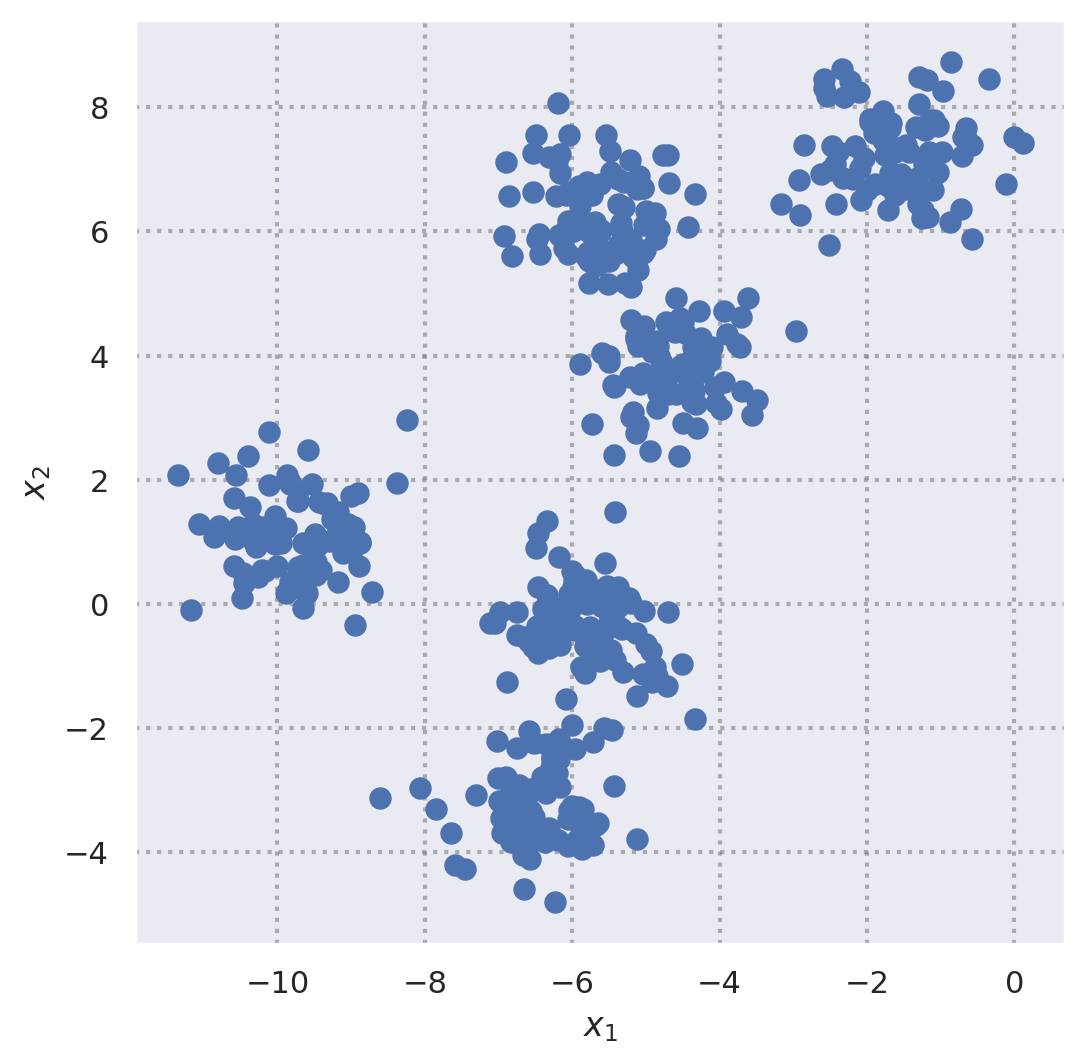

In [3]:
from sklearn.datasets import make_blobs

rng = np.random.RandomState(36)

X, y_true = make_blobs(n_samples=500, centers=6,
                       cluster_std=0.6, random_state=22)

plt.scatter(X[:, 0], X[:, 1], s=50)
plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()

In [4]:
from sklearn.cluster import KMeans

# K-means with K=6.
K=6

kmeans = KMeans(n_clusters=K, random_state=42) # Create model, non-give arguments set to their default value
kmeans.fit(X) # Learn centroids
y_kmeans = kmeans.predict(X) # get cluster memberships of training data
centers = kmeans.cluster_centers_ # get centroids

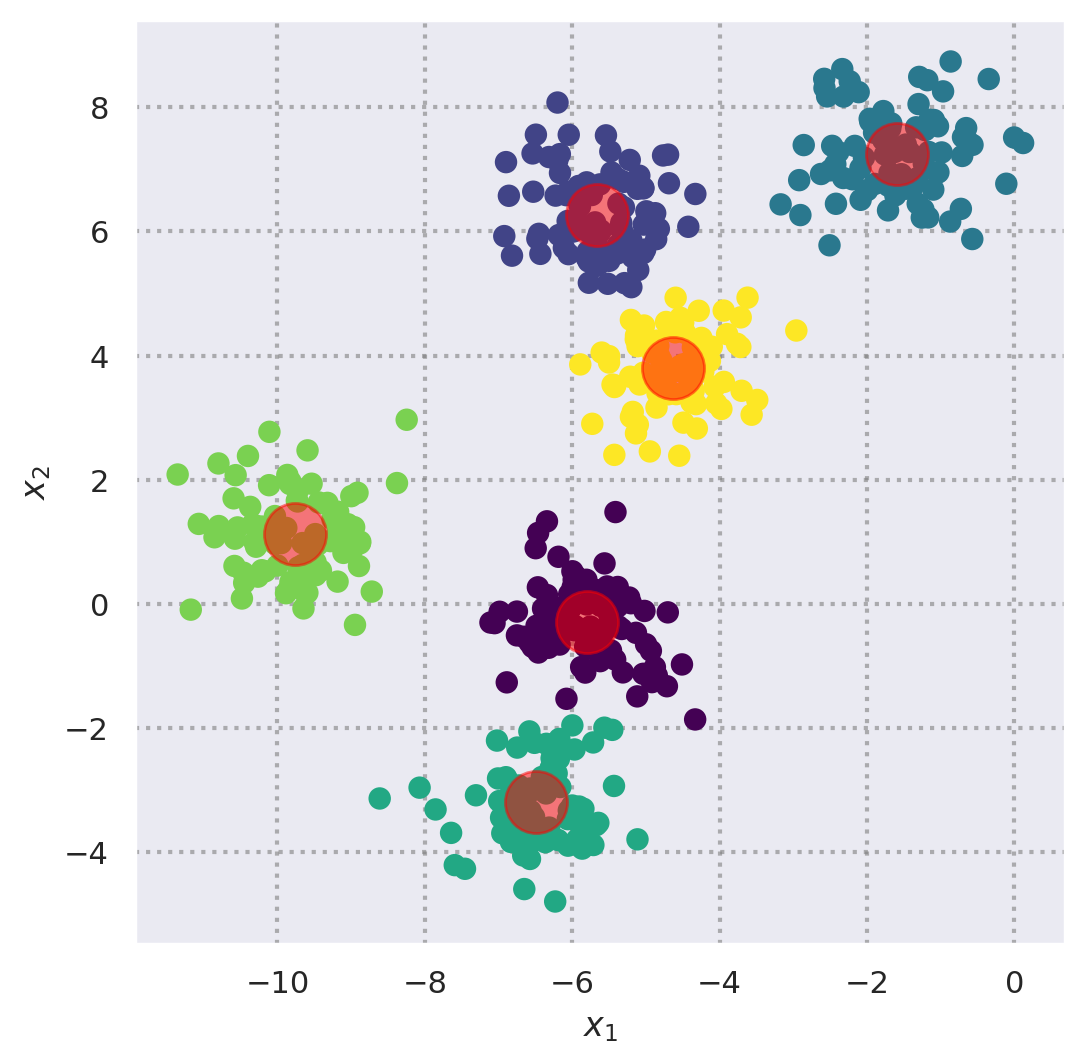

In [5]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

plt.scatter(centers[:, 0], centers[:, 1], c='red', s=500, alpha=0.5)

plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()

Now slow-motion to observe convergence


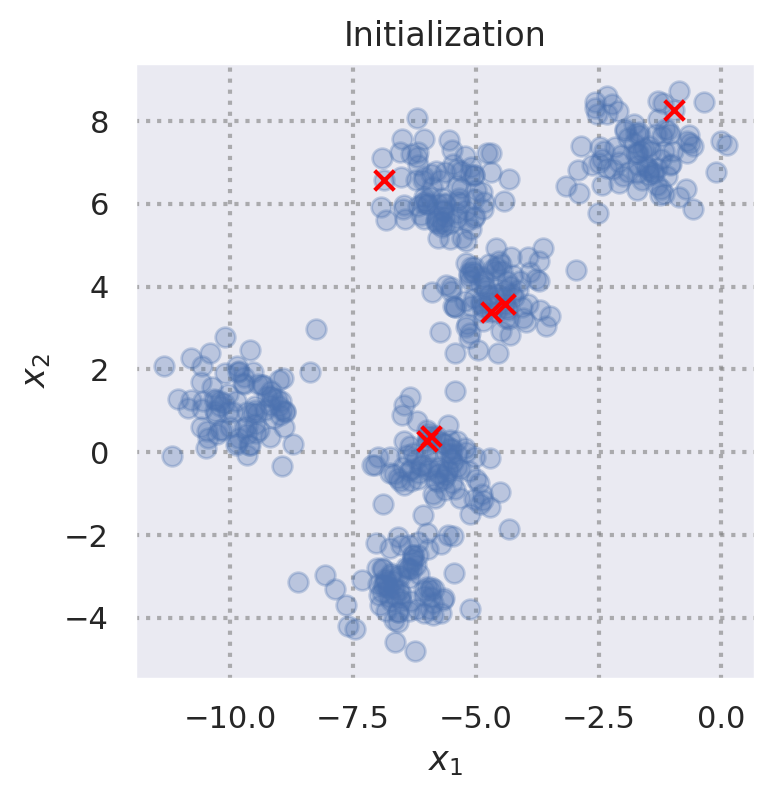

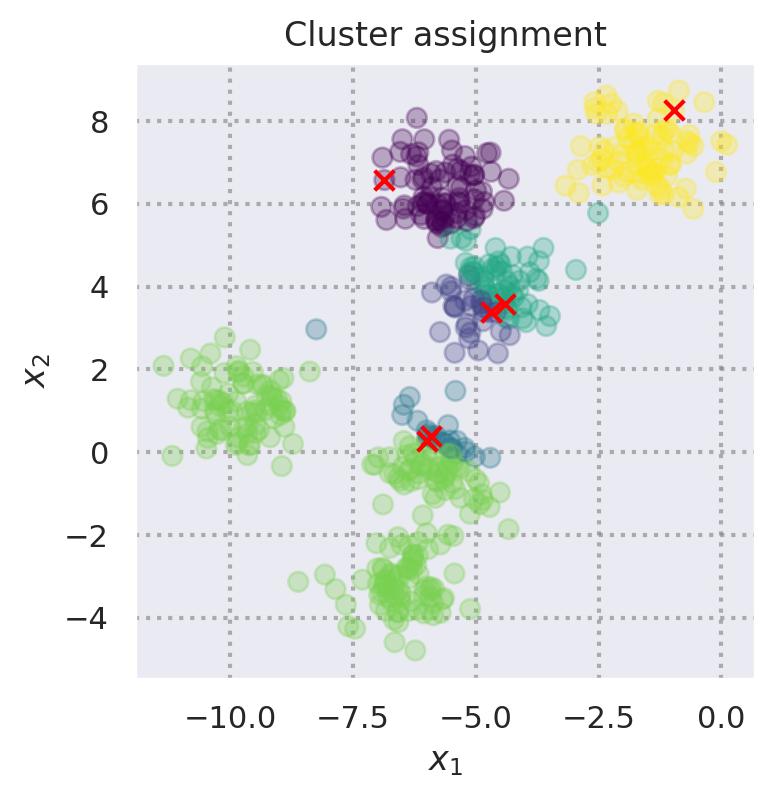

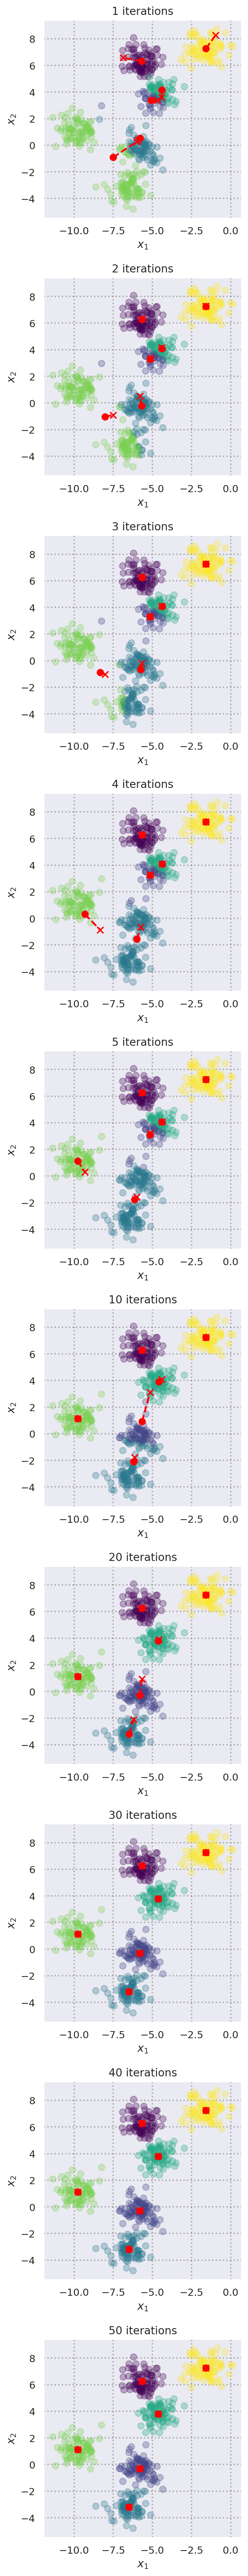

In [6]:
K=6
v_iter = [1, 2, 3, 4, 5, 10, 20, 30, 40, 50]

plt.figure(figsize=(4,4))
old_centers =X[:K,:]
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.3)
plt.scatter(old_centers[:, 0], old_centers[:, 1],
            c='red',
            s=50,
            marker='x')

plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Initialization')
plt.show()


kmeans = KMeans(n_clusters=K,
                   n_init=1,
                    init=X[:K,:],
                   max_iter=1,
                    tol=0.0001,
                    verbose=0,
                    random_state=42,
                    )
kmeans.fit(X)
kmeans.cluster_centers_ = X[:K,:]
y_kmeans = kmeans.predict(X)
plt.figure(figsize=(4,4))
old_centers =X[:K,:]
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', alpha=0.3)
plt.scatter(old_centers[:, 0], old_centers[:, 1],
            c='red',
            s=50,
            marker='x')

plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Cluster assignment')
plt.show()


ff, aa = plt.subplots(len(v_iter), 1, figsize=(4,4*len(v_iter)))


for ii,iters in enumerate(v_iter):
    #print(old_centers)
    kmeans = KMeans(n_clusters=K,
                   n_init=1,
                    init=X[:K,:],
                   max_iter=iters,
                    tol=0.0001,
                    verbose=0,
                    random_state=42,
                    )
    kmeans.fit(X)
    y_kmeans = kmeans.predict(X)
    centers = kmeans.cluster_centers_.copy()

    aa[ii].scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', alpha=0.3)
    aa[ii].scatter(old_centers[:, 0], old_centers[:, 1], c='red', s=50, marker='x')
    aa[ii].scatter(centers[:, 0], centers[:, 1], c='red', s=50)
    for jj in range(K):
        aa[ii].plot([centers[jj,0], old_centers[jj,0]],
                    [centers[jj,1], old_centers[jj,1]],
                   lw=2,
                   ls='--',
                   color='red')
    aa[ii].grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
    aa[ii].set_xlabel('$x_1$')
    aa[ii].set_ylabel('$x_2$')
    aa[ii].set_title('{0:d} iterations'.format(iters))
    old_centers = centers.copy()
ff.tight_layout()

## Dependence with the initialization of the clusters
---

The convergence of Kmeans is guaranteed, but it converges to a local optimum, and this optimum depends of the initial state.

Let's examine the dependence with the initialization in the toy scenario. We show the initial set of centroids with a red triangle in the following figures.


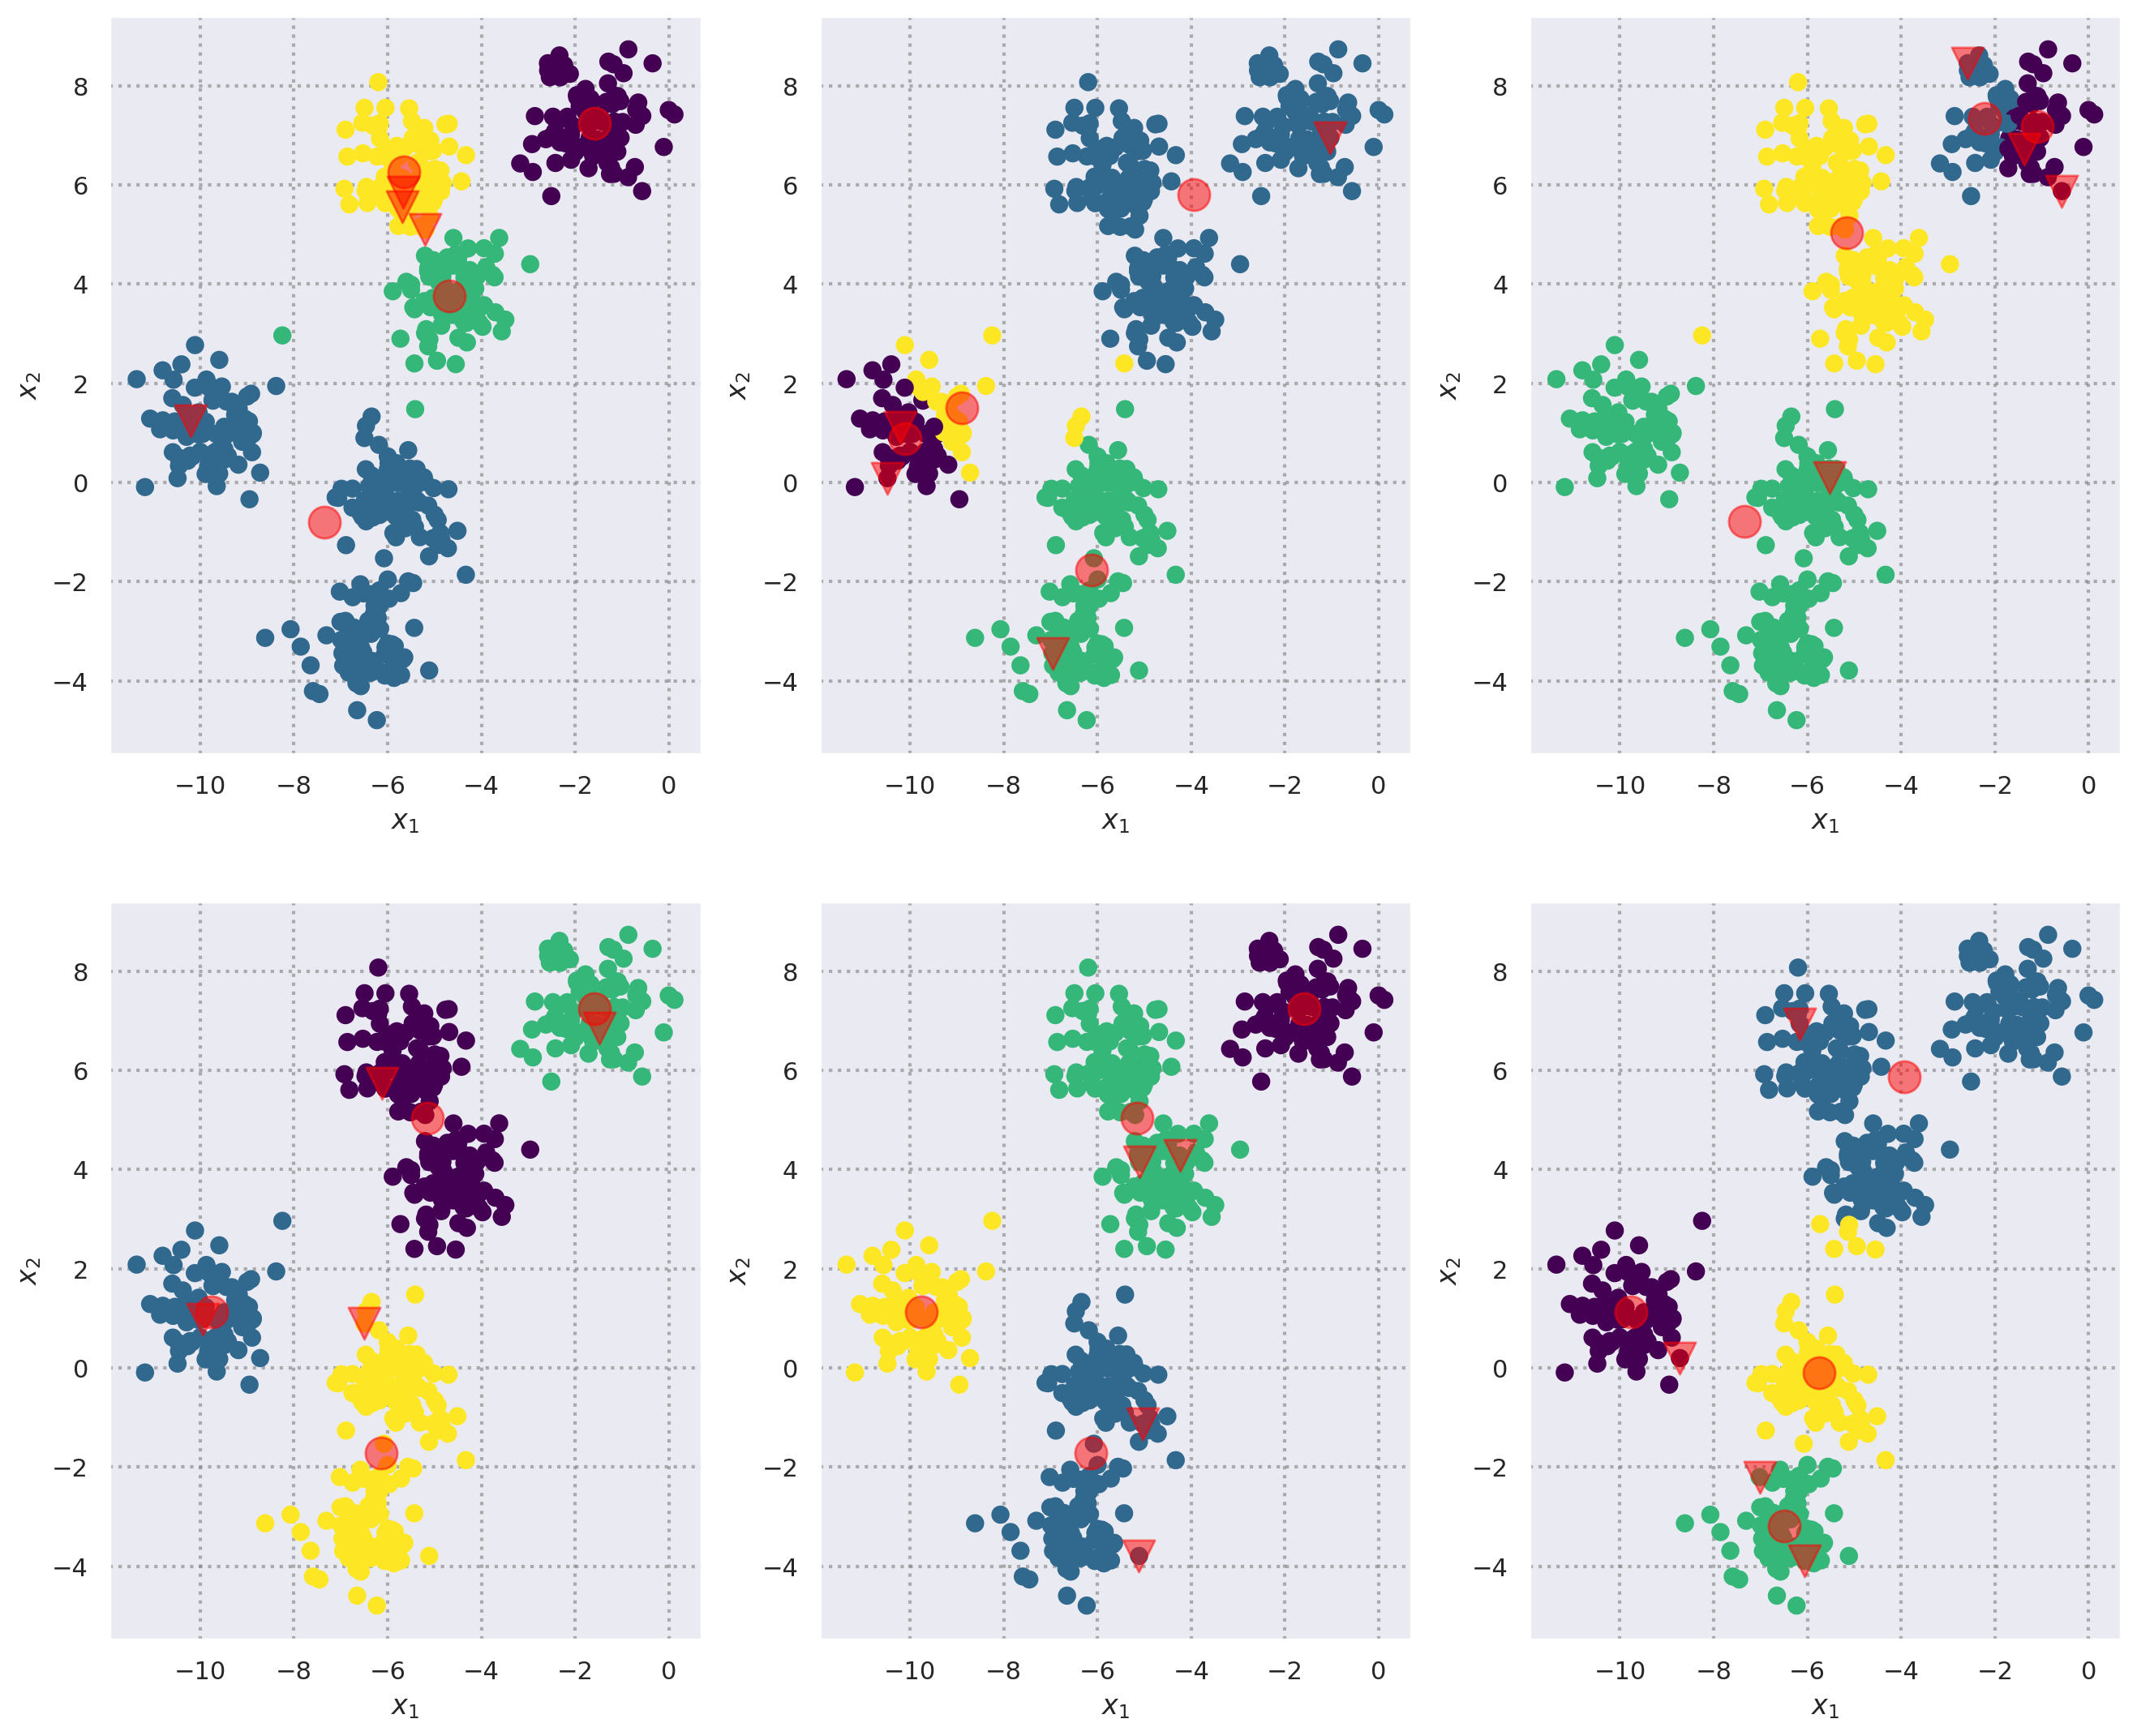

In [7]:
n_plots_row = 3
n_rows = 2
rs = 45
K=4
fig, ax = plt.subplots(nrows=n_rows, ncols=n_plots_row, figsize=(16, 13))

for r in range(n_rows):
    for c in range(n_plots_row):

        # Random initialization
        centers_idx = np.random.permutation(X.shape[0])[:4]
        init_centroids = X[centers_idx,:]
        kmeans = KMeans(n_clusters=K,init=init_centroids,n_init=1,random_state=rs)
        kmeans.fit(X)
        y_kmeans = kmeans.predict(X)

        centers = kmeans.cluster_centers_

        ax[r,c].scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
        ax[r,c].scatter(init_centroids[:,0], init_centroids[:, 1], c='red', s=200, alpha=0.5,
                        marker="v",label='initialization')
        ax[r,c].scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5,label='Centroid k-means')
        ax[r,c].grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)

        ax[r,c].set_xlabel('$x_1$')
        ax[r,c].set_ylabel('$x_2$')


The way to overcome this situation is to start several initializations and select as final clustering the one that presents more compact clusters.

In sklearn this can be controlled with the argument `n_init`. Besides, there is another argument, `init`, that enables the use of different (smarter) ways of selecting the initial set of centroids.

## Cost function of Kmeans
---

The iterative optimization of the Kmeans algorithm aims at solving the following problem

\begin{align}
\min_{\mathbf{c}_1,\ldots,\mathbf{c}_K} \mathcal{L}(\mathbf{c}_1,\ldots,\mathbf{c}_K) = \min_{\mathbf{c}_1,\ldots,\mathbf{c}_K} \frac{1}{n} \sum_{k=1}^K \sum_{\mathbf x_j \in C_k} d(\mathbf{x}_j,\mathbf{c}_k)
\end{align}

notice that the cost function $\mathcal{L}(\mathbf{c}_1,\ldots,\mathbf{c}_K)$ is the **average of the distances from each observation to the centroid of its cluster**. Kmeans' goal is to minimize this quantity. However, as we said before, this cost function presents several local minima.

An option to determine a robust Kmeans final solution is to  choose the clustering that minimizes $\mathcal{L}(\mathbf{c}_1,\ldots,\mathbf{c}_K)$ after repeating the algorithm a certain number of times with different initializations. In the  [sklearn implementation of Kmeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) we access the value of $\mathcal{L}(\mathbf{c}_1,\ldots,\mathbf{c}_K)$ through the attribute `inertia_` divided by the number of training instances.

In the toy example with several initializations that we saw before:


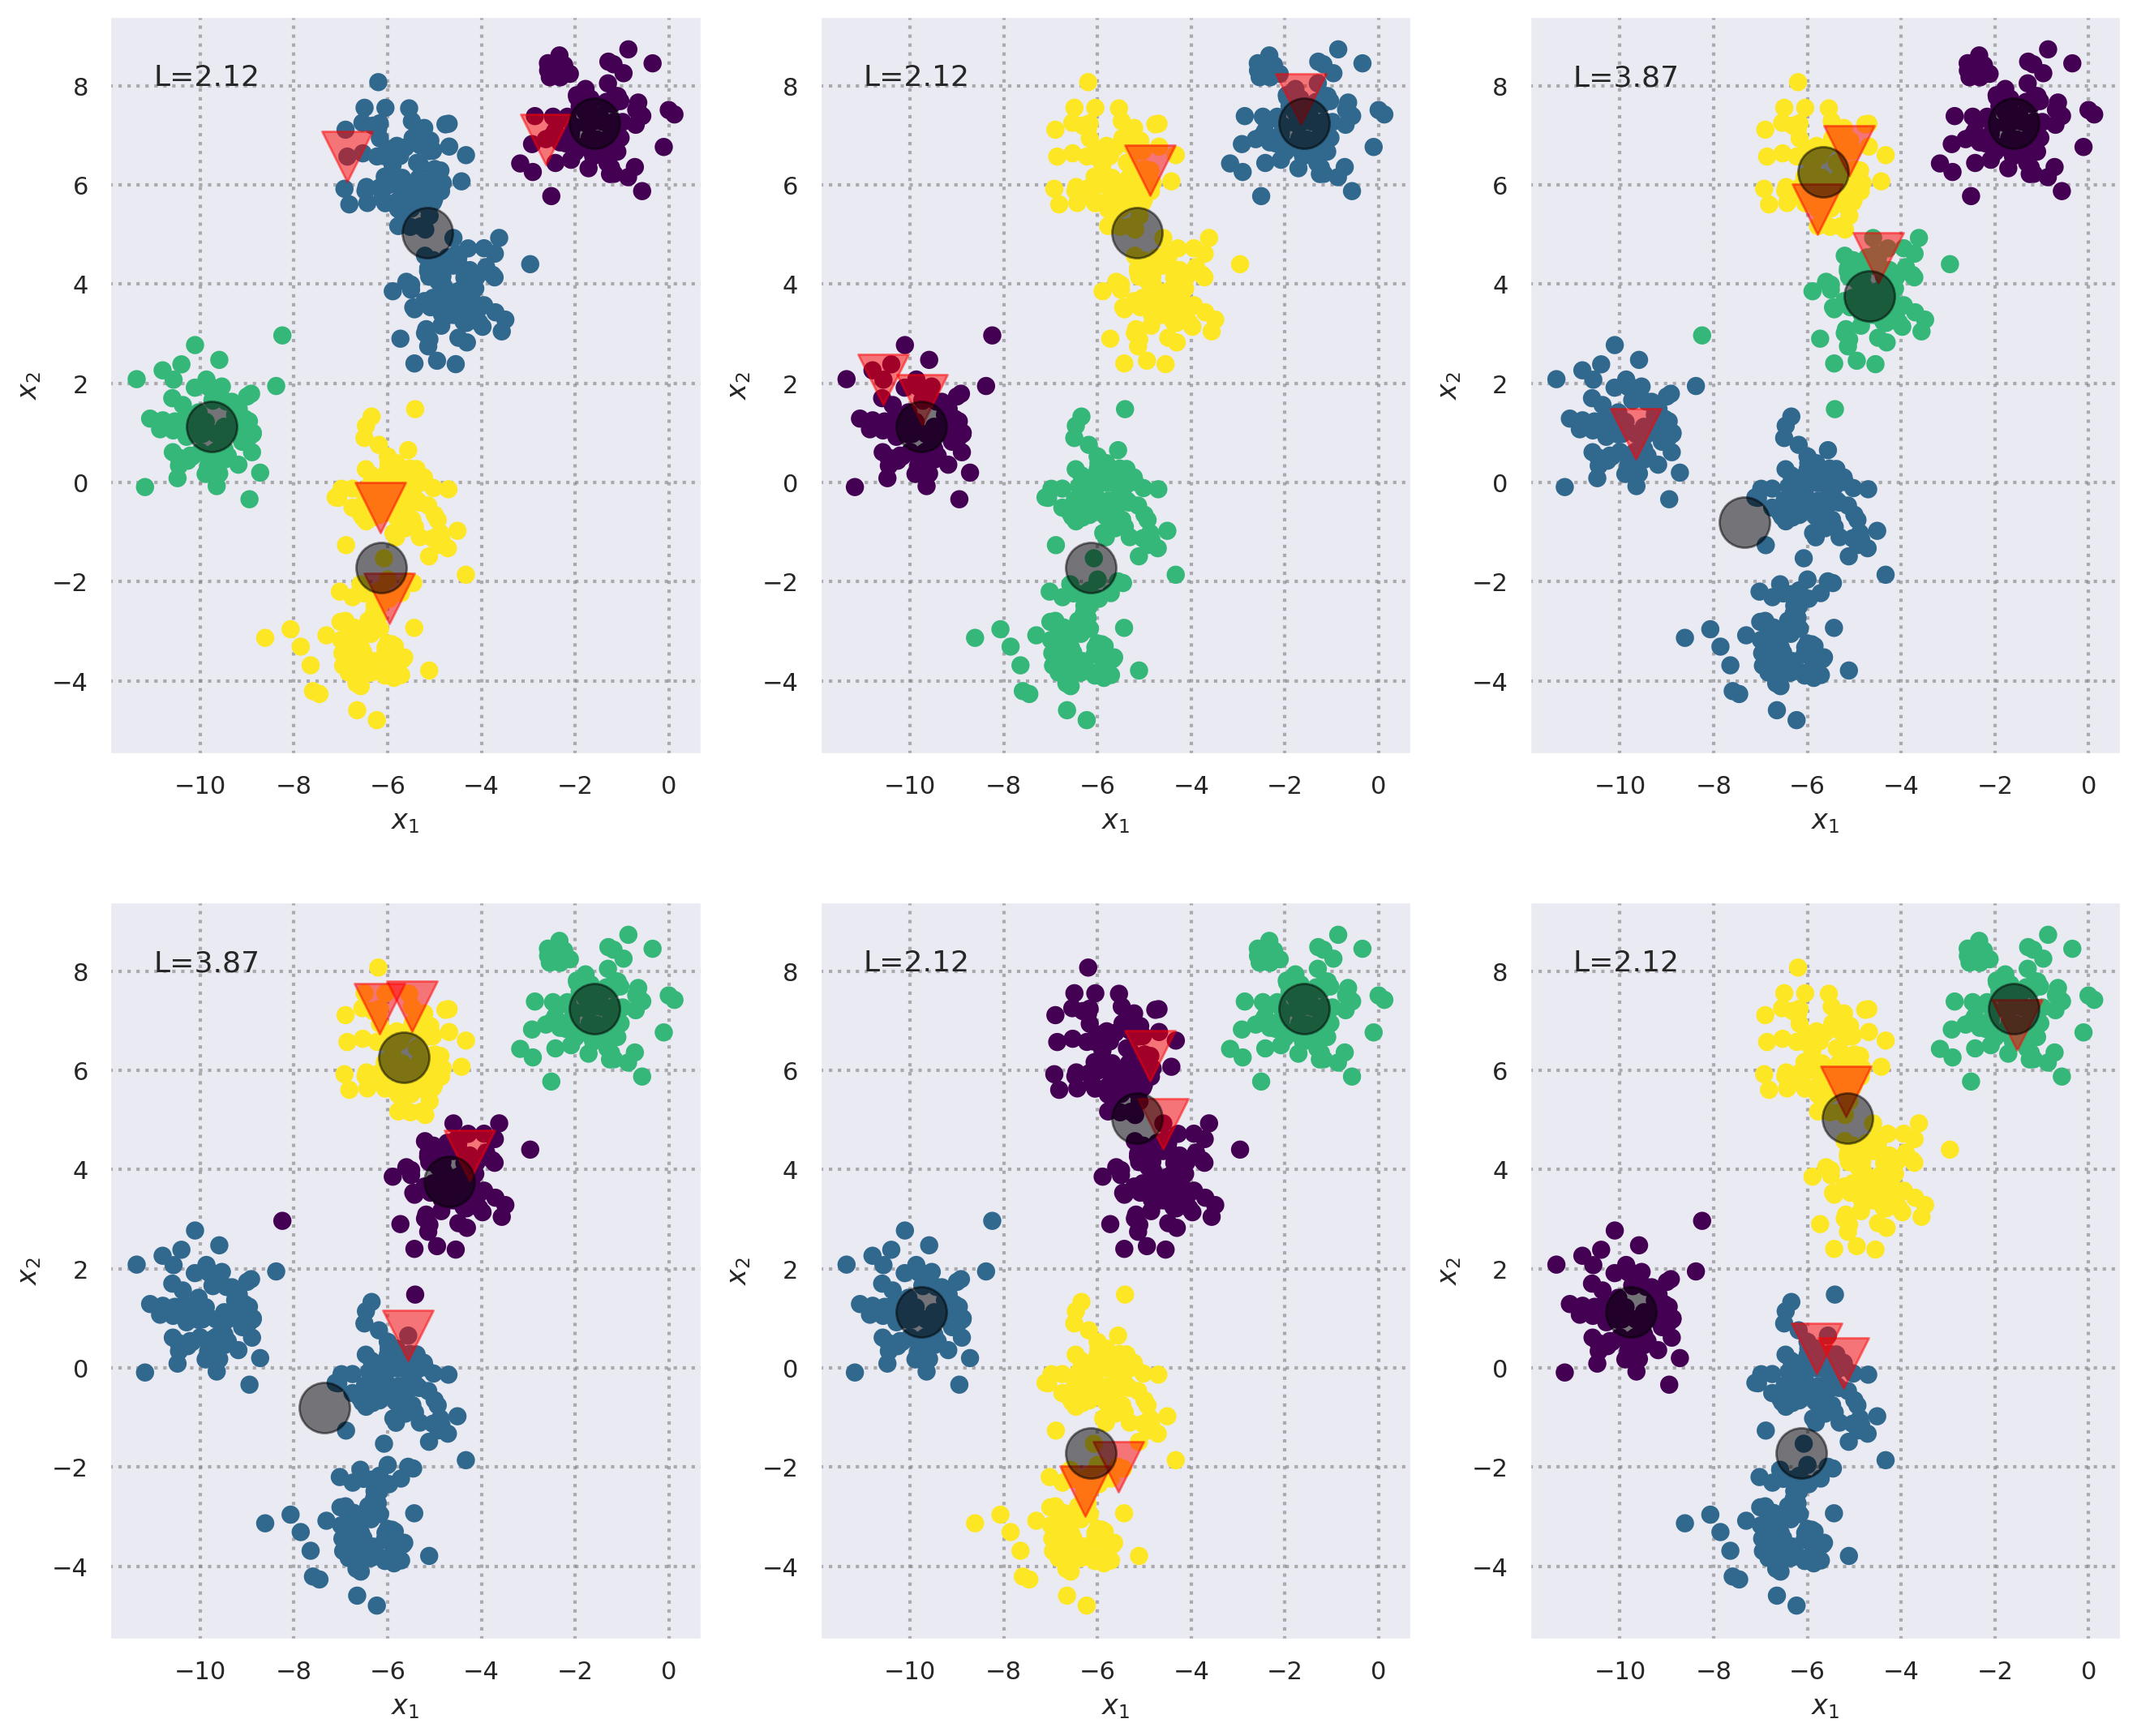

In [8]:
n_plots_row = 3
n_rows = 2
rs = 45

fig, ax = plt.subplots(nrows=n_rows, ncols=n_plots_row, figsize=(16, 13))

for r in range(n_rows):
    for c in range(n_plots_row):


        centers_idx = np.random.permutation(X.shape[0])[:4]
        init_centroids = X[centers_idx,:]
        kmeans = KMeans(n_clusters=K,init=init_centroids,n_init=1,random_state=rs)
        kmeans.fit(X)
        y_kmeans = kmeans.predict(X)

        centers = kmeans.cluster_centers_

        ax[r,c].scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
        ax[r,c].scatter(init_centroids[:,0], init_centroids[:, 1], c='red', s=500, alpha=0.5,
                        marker="v",label='initialization')
        ax[r,c].scatter(centers[:, 0], centers[:, 1], c='black', s=500, alpha=0.5,label='Centroid k-means')
        ax[r,c].grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
        ax[r,c].text(-11, 8, 'L={0:.2f}'.format(kmeans.inertia_/X.shape[0]), fontsize=13)
        ax[r,c].set_xlabel('$x_1$')
        ax[r,c].set_ylabel('$x_2$')

As we anticipated, `n_init` can take care of handling different initializations automatically

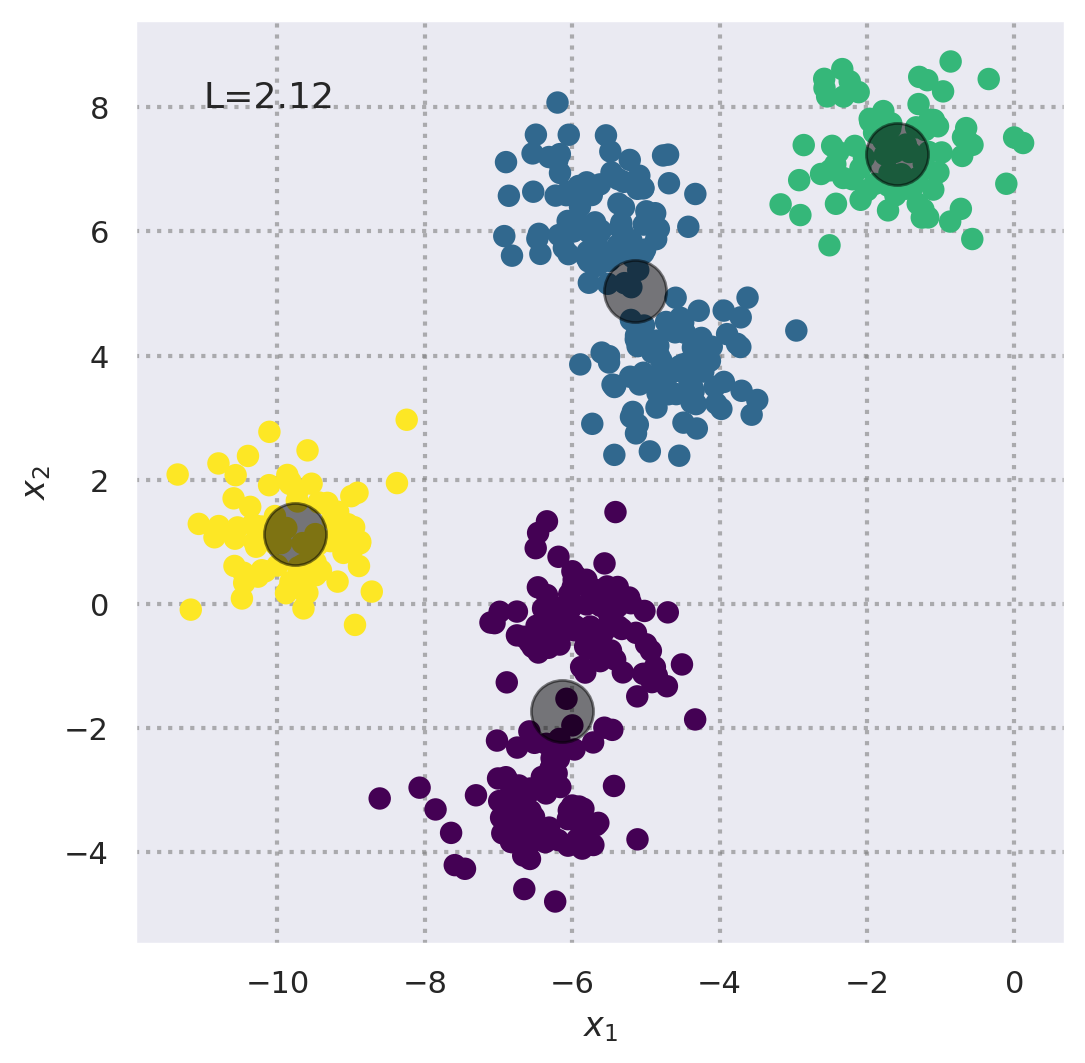

In [9]:
K=4

kmeans = KMeans(n_clusters=K,n_init=10)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)
centers = kmeans.cluster_centers_

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

plt.scatter(centers[:, 0], centers[:, 1], c='black', s=500, alpha=0.5)

plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.text(-11, 8, 'L={0:.2f}'.format(kmeans.inertia_/X.shape[0]), fontsize=13)
plt.show()

## Dependence with K
---

We can reproduce the previous experiment with different values of $K$, and decide if the groupings make sense



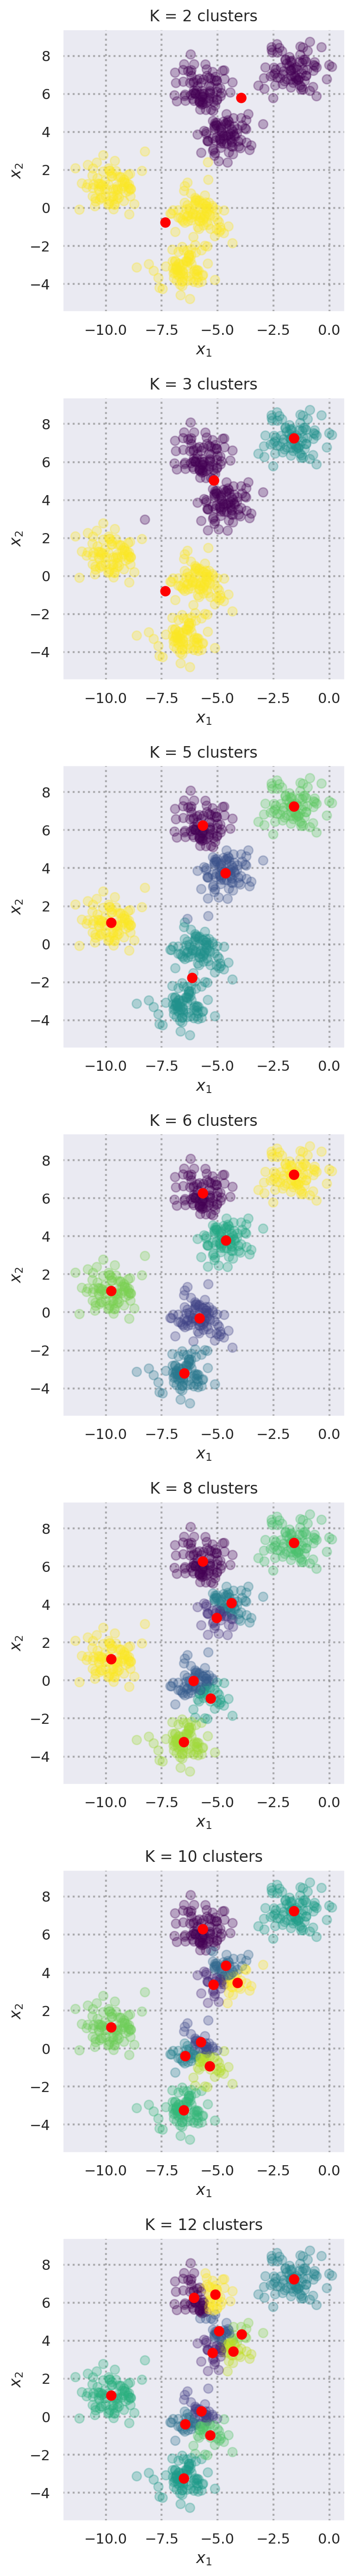

In [10]:
v_K = [2,3,5,6,8,10,12]
ff, aa = plt.subplots(len(v_K), 1, figsize=(4,4*len(v_K)))


for ii,K in enumerate(v_K):

    kmeans = KMeans(n_clusters=K,
                   n_init=1,
                    init=X[:K,:],
                   max_iter=100,
                    tol=0.0001,
                    verbose=0,
                    random_state=42,
                    )
    kmeans.fit(X)
    y_kmeans = kmeans.predict(X)
    centers = kmeans.cluster_centers_.copy()

    aa[ii].scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', alpha=0.3)
    aa[ii].scatter(centers[:, 0], centers[:, 1], c='red', s=50)
    aa[ii].grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
    aa[ii].set_xlabel('$x_1$')
    aa[ii].set_ylabel('$x_2$')
    aa[ii].set_title('K = {0:d} clusters'.format(K))
    old_centers = centers.copy()
ff.tight_layout()

## Choosing $K$
---

The selection of $K$ is critical in Kmeans.

- If the **interpretability** of the groups is a major goal, the strategy will be to explore a wide range of values of  $K=2,3, ...$ and get an expert in the problem validate which is the most explainable cluster configuration

- Additionally one can use the cost function $\mathcal{L}(\mathbf{c}_1,\ldots,\mathbf{c}_K)$, but here one needs to be careful:

In [11]:
K_list = range(2,20)

L = []

for k in K_list:

    kmeans = KMeans(n_clusters=k,n_init = 10) # 10 different inits per each value of K
    kmeans.fit(X)
    L.append((kmeans.inertia_)/(X.shape[0]))

# clustering with the last value of K explored

y_kmeans = kmeans.predict(X) # cluster membership for each data
centers = kmeans.cluster_centers_

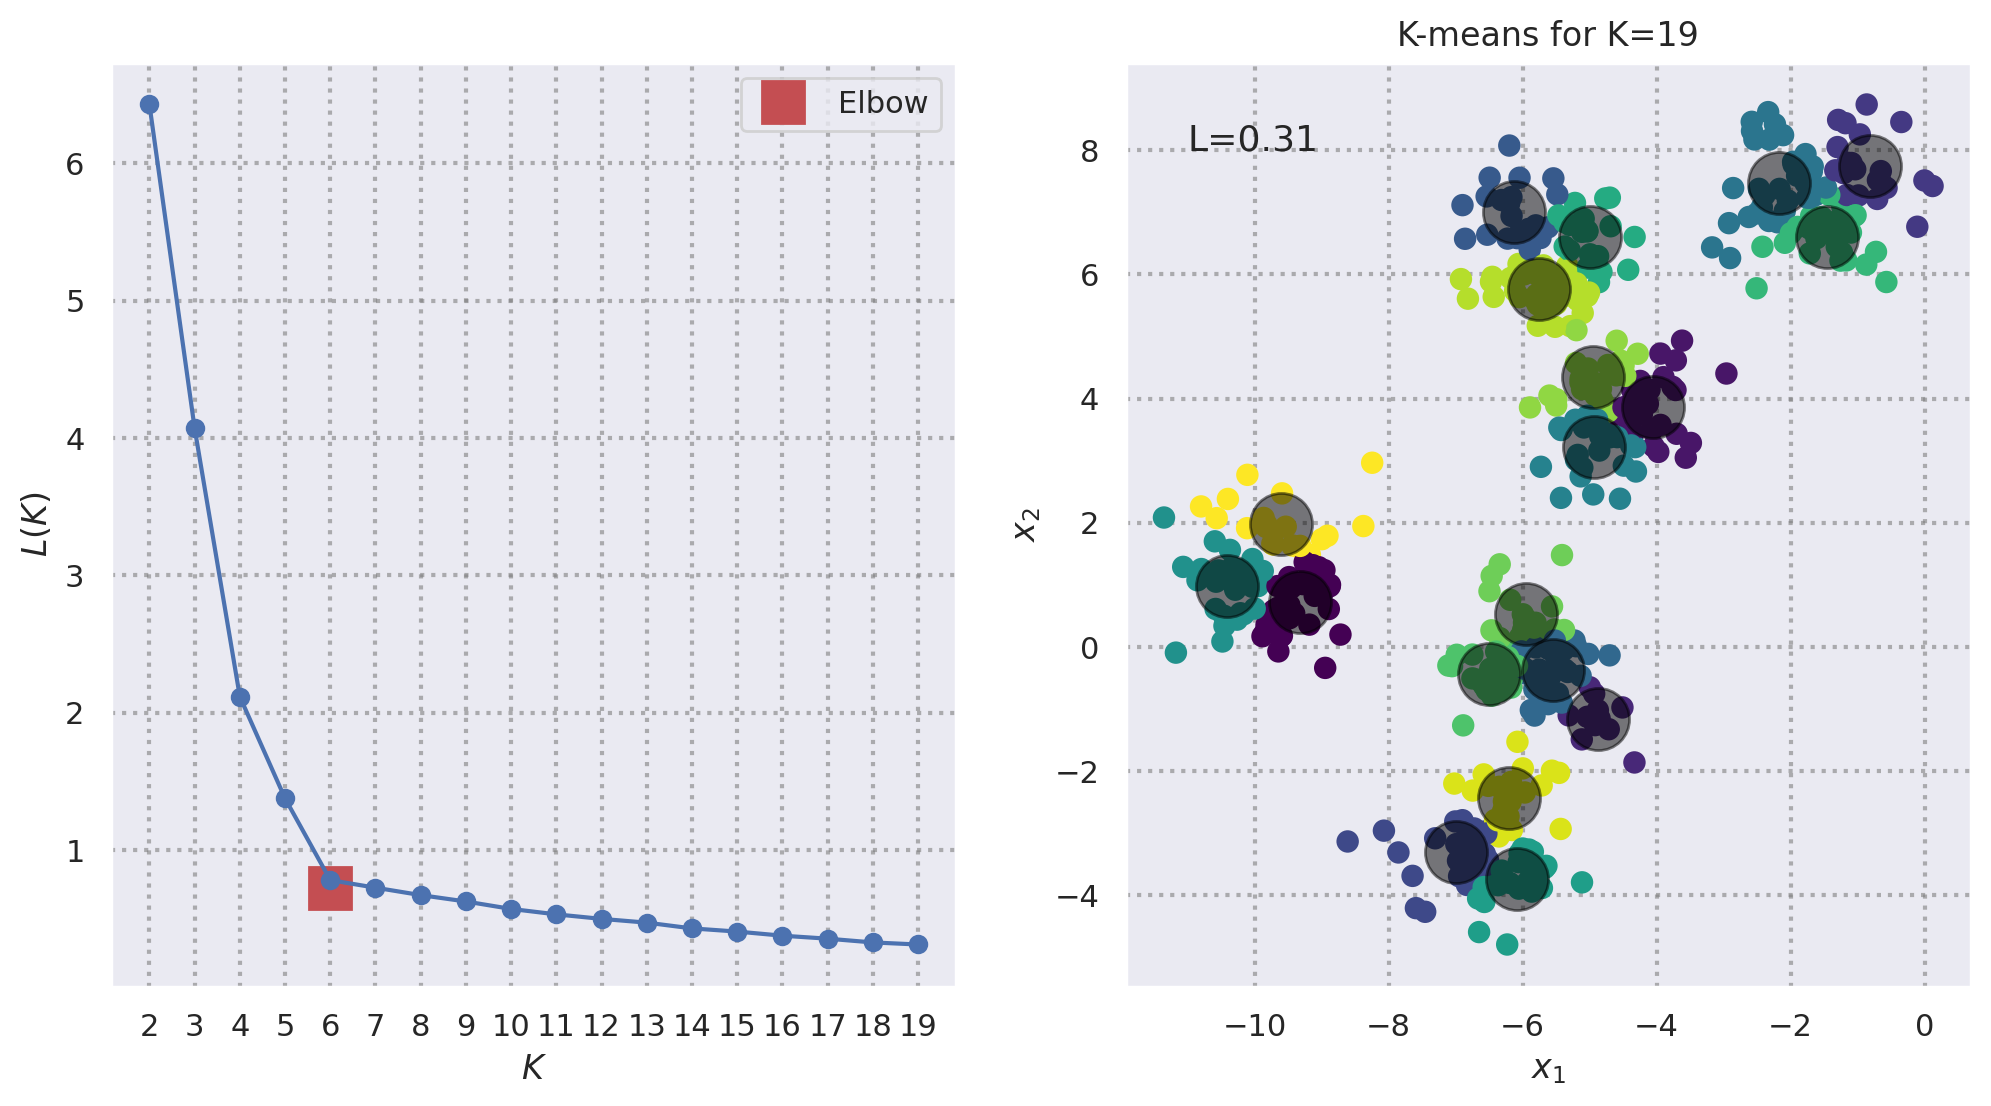

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

ax[0].plot(6,L[5],'rs',ms=15,label='Elbow')
ax[0].plot(K_list,L,'-o')
ax[0].legend()

ax[0].set_xlabel('$K$')
ax[0].set_ylabel('$L(K)$')
ax[0].grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
ax[0].set_xticks(K_list);

ax[1].scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

ax[1].scatter(centers[:, 0], centers[:, 1], c='black', s=500, alpha=0.5)

ax[1].grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)

ax[1].set_xlabel('$x_1$')
ax[1].set_ylabel('$x_2$')
ax[1].text(-11, 8, 'L={0:.2f}'.format(kmeans.inertia_/X.shape[0]), fontsize=13)
_=ax[1].set_title('K-means for K={0:d}'.format(K_list[-1]))



Notice that $L(K)$ is monotonic decreasing with $K$. In fact, for $K=N$ we'll get a single instance per group and then $L(K=N)=0$. This is a clear sign of **overfitting**.

In general, we will look for those values of $K$ from which $L(K)$ starts to decrease more softly. This is like looking for the **elbow of the curve**. In the toy problem we can consider  $K=6$ to mark the elbow, precisely the number of groups that we declared in the generation of thedataset.

##  Silhouette score
---

As an alternative to the analysis of $L(K)$ for the determination of the number of clusters  $K$, onen can use the [silhouette score](https://en.wikipedia.org/wiki/Silhouette_(clustering)). This value is a measure of how similar is every data to its own cluster in comparison to its similarity with other clusters.

For a particular data $\mathbf{x}_i$, the silhouette score is computed with the following procedure:

1. Compute the $a(\mathbf{x}_i)$, that is, the average distance between $\mathbf x_i$ and all the other data that belong to its cluster. If $\mathbf x_i$ belongs to $C_i$, and there are $N_i$ data in $C_i$, then
$$
a(\mathbf{x}_i) = \frac{1}{N_i-1} \sum_{\mathbf{x}_j\in C_i, j \ne i} d(\mathbf{x}_i,\mathbf{x}_j)
$$

2. Compute the average distance between $\mathbf x_i$ and all the data in **the closest cluster** to  $\mathbf x_i$. The closest cluster means that in a clustering in $K$ groups, $\mathbf x_i$ was assigned to $C_i$ but there will be a second runner up cluster $C_b$. Then
$$
b(\mathbf{x}_i) = \min_{k=1,\ldots,K \\ k \ne i} \frac{1}{N_k} \sum_{\mathbf{x}_j\in C_k}{d(\mathbf{x}_i,\mathbf{x}_j)}
$$
The minimum operator sirves to identify the second runner up cluster among all the clusters that are not the one that includes $\mathbf{x}_i$. That is, the minimum operator gets $C_b$ out of the $K-1$ clusters $C_k$ with $k=1,\ldots, K$, $k \ne i$

3. Then the silhouette score is computed as

$$ s(\mathbf{x}_i) = \frac{b(\mathbf{x}_i)-a(\mathbf{x}_i)}{\max\Big\{b(\mathbf{x}_i),a(\mathbf{x}_i)\Big\}}$$


The value of the silhouette score is in $[-1, 1]$. A score of $1$ means that $\mathbf{x}_i$ is very well represented within its group (cohesion), as it is very similar to all the members of its group and very different from the members of the other groups (separation). An score of $-1$ indicates a poor clustering, as points do not get well represented by their own clusters. Values close to 0 indicate overlapping groups.

In [Sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) we can obtain the average value of the score for all the points, that is, this function provides the mean of the Silhouette score for each sample.

Silhouette score for different values of $K$ in the toy problem.

In [13]:
from sklearn.metrics import silhouette_score

K_list = range(2,20)

L = []
SC = []

for k in K_list:

    kmeans = KMeans(n_clusters=k,n_init = 10)
    kmeans.fit(X)
    L.append((kmeans.inertia_)/(X.shape[0]))
    y_kmeans = kmeans.predict(X)
    SC.append(silhouette_score(X,y_kmeans))

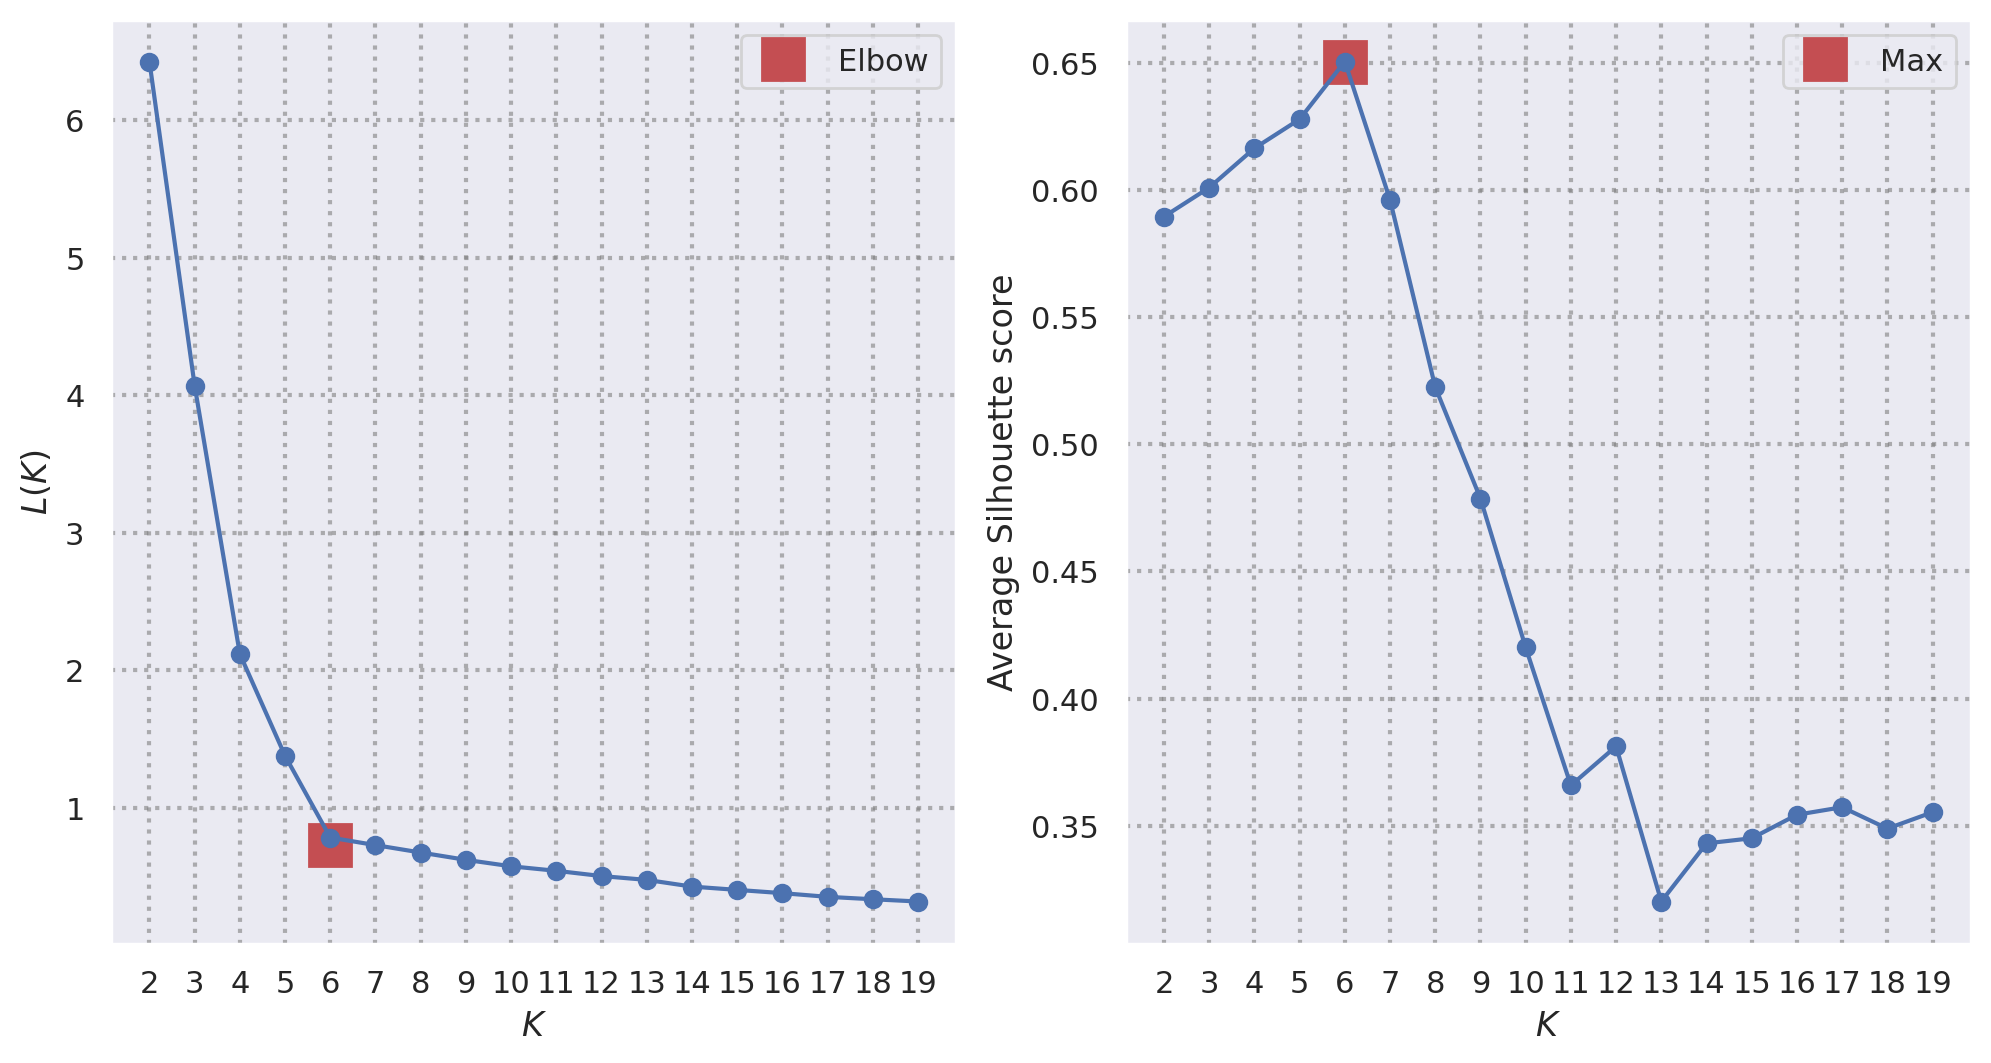

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

ax[0].plot(6,L[5],'rs',ms=15,label='Elbow')
ax[0].plot(K_list,L,'-o')
ax[0].legend()
ax[0].set_xticks(K_list);

ax[0].set_xlabel('$K$')
ax[0].set_ylabel('$L(K)$')
ax[0].grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)

#ax[1].plot(6,L[5],'rs',ms=15,label='Codo')
ax[1].plot(K_list[np.argmax(SC)],np.max(SC),'rs',ms=15,label='Max')
ax[1].plot(K_list,SC,'-o')
ax[1].legend()

ax[1].set_xlabel('$K$')
ax[1].set_ylabel('Average Silhouette score')
ax[1].grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
ax[1].set_xticks(K_list);


## Spherical symmetry of the groups

The use of the Euclidean distance and the centroids to define the groups makes them present the form of a *ball* whose center is the centroid: all the points that are at the same distance from this centroid present the same *degree of belonging* to the group.


Let's consider a problem with a less typical geometry

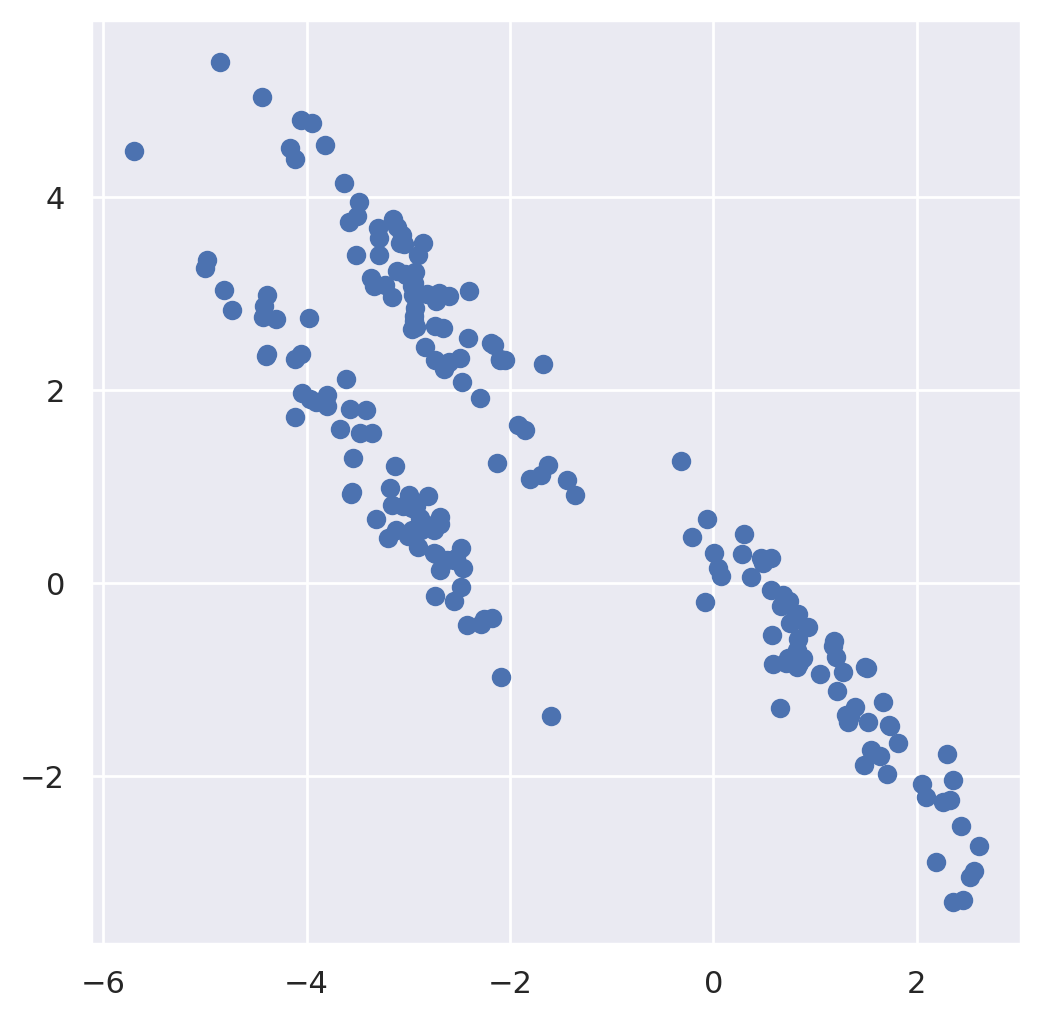

In [15]:
from sklearn import datasets

random_state = 170
n_samples = 200
Xs, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X = np.dot(Xs, transformation)
plt.figure()
_=plt.scatter(X[:,0], X[:,1])

In [16]:
K=3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10) # Create model, non-give arguments set to their default value
kmeans.fit(X) # Learn centroids
y_kmeans = kmeans.predict(X) # get cluster memberships of training data
centers = kmeans.cluster_centers_ # get centroids

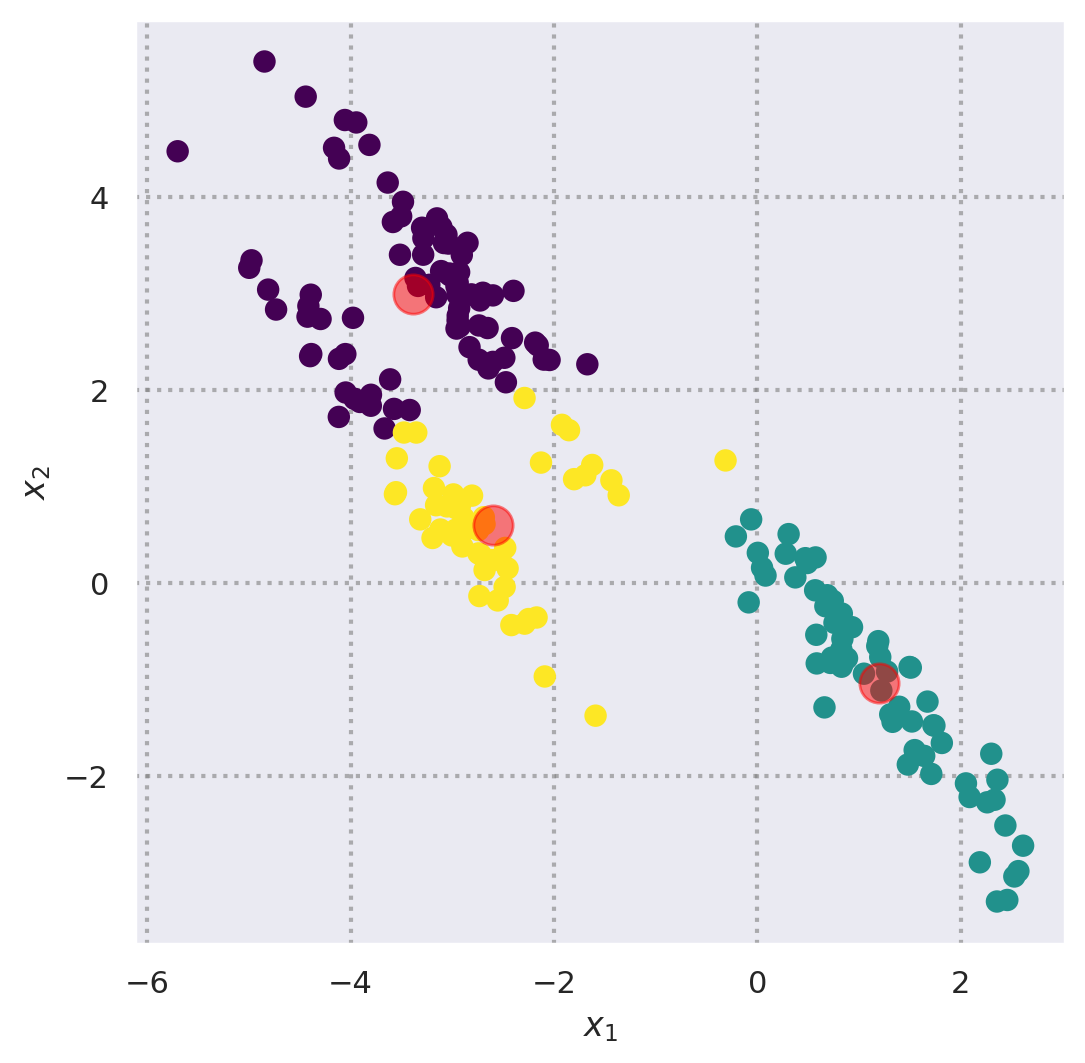

In [17]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)
plt.grid(visible=True, which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()

Was this the grouping you were expecting? I hope not!

Let's try another dataset

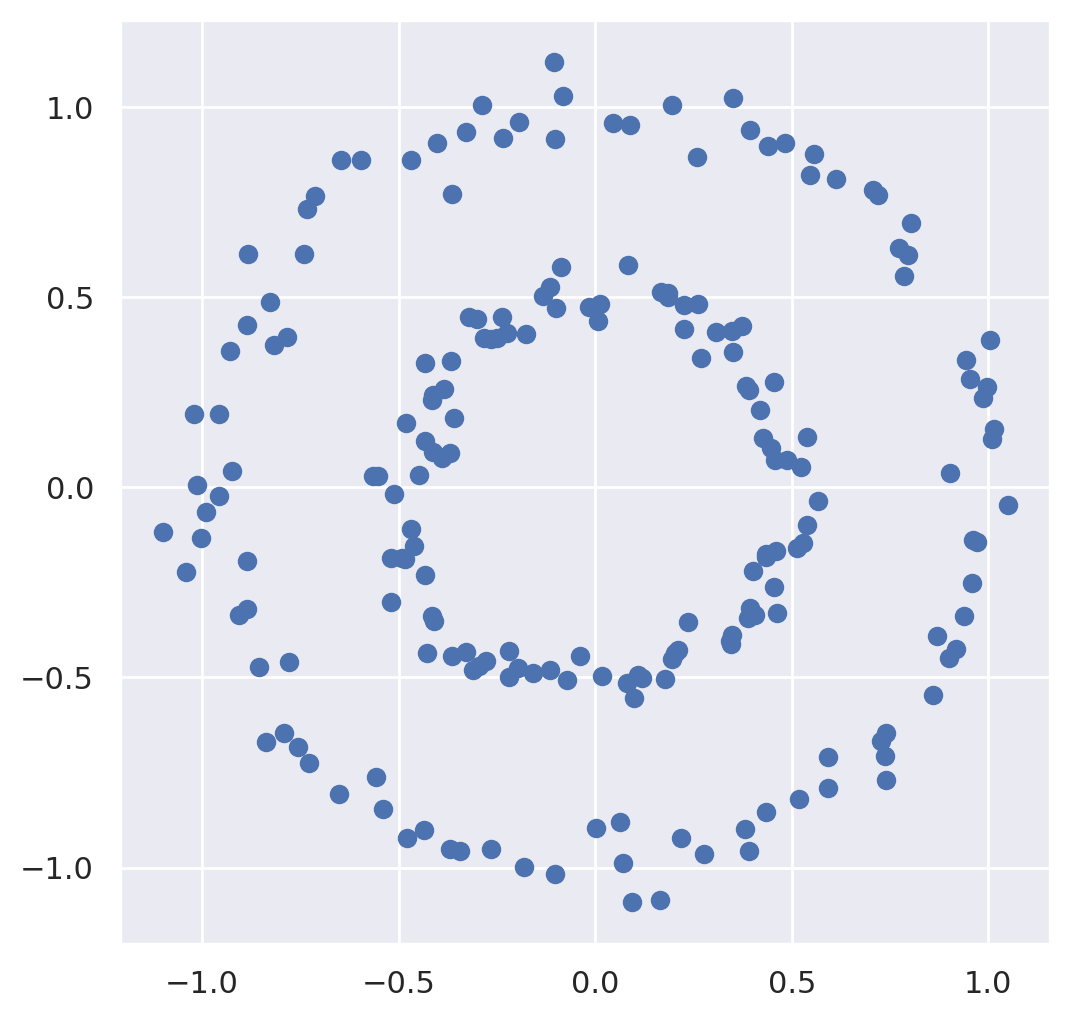

In [18]:
X = datasets.make_circles(n_samples=n_samples, factor=.5,
                                      noise=.05)[0]
plt.figure()
_=plt.scatter(X[:,0], X[:,1])

In [19]:
K=2
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10) # Create model, non-give arguments set to their default value
kmeans.fit(X) # Learn centroids
y_kmeans = kmeans.predict(X) # get cluster memberships of training data
centers = kmeans.cluster_centers_ # get centroids

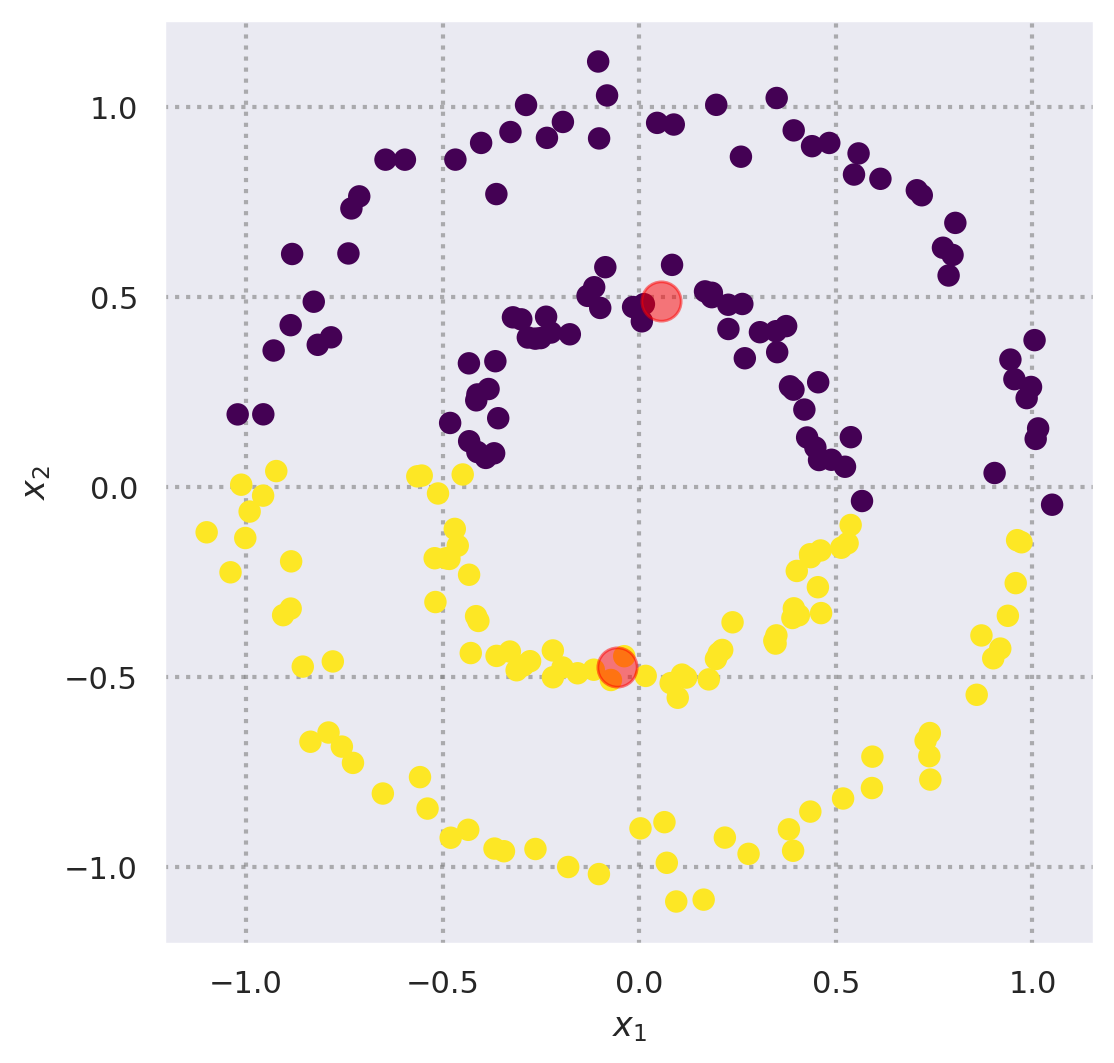

In [20]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)
plt.grid(visible=True, which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()

What about this one?